# S06: Canonicalizing Atom-Mapped Reactions and Rules

This talktorial explains why atom-map numbers must be canonicalized before reactions and extracted rules can be compared reproducibly. We use partition refinement, WL-style coloring, and exact isomorphism ideas to collapse equivalent maps [\[1\]](#6.-References), [\[2\]](#6.-References), [\[3\]](#6.-References).


## Aim of this talktorial

1. Use **partition and refinement** to distinguish atoms by local structural context.
2. Resolve ambiguous symmetric atoms with **individualization and exact methods**.
3. Canonicalize atom-mapped reaction SMILES and quantify the effect on rule deduplication.

---

## Learning outcomes

After completing this talktorial, you will be able to:

- explain why atom maps are non-unique and why map numbers should be canonicalized,
- define graph partitions, equitable refinement, and WL-style color refinement,
- implement a deterministic atom-map reindexing $\pi: \mathbb{N} \to \mathbb{N}$ based on map-invariant structural ranks,
- canonicalize mapped reaction SMILES by molecule order and map IDs without changing chemistry,
- identify cases where refinement leaves unresolved symmetry, and
- quantify how canonicalization affects the number of unique centers or rules using hashes and isomorphism checks.

---

## Outline

- [0. Setup & data](#0.-Setup-&-data)
- [1. Partition, Refinement and Approximation](#1.-Partition,-Refinement-and-Approximation)
- [2. Individualization, Refinement, and Exact Methods](#2.-Individualization,-Refinement,-and-Exact-Methods)
- [3. Atom-Mapped Canonicalization](#3.-Atom-Mapped-Canonicalization)
- [4. Discussion](#4.-Discussion)
- [5. Quiz](#5.-Quiz)
- [6. References](#6.-References)

## 0. Setup & data


In [2]:
import rdkit
import pandas as pd
import networkx as nx
from pathlib import Path
from synedu.Utils import load_database

print("RDKit version:", rdkit.__version__)
print("NetworkX version:", nx.__version__)

DATA_DIR = Path("data")
DATA_PATH = DATA_DIR / "data_aam.json.gz"
data = pd.DataFrame(load_database(DATA_PATH)[:2000])  # 2000 rows for manageable runtime
display(data.head())
print(data.shape)

RDKit version: 2025.09.3
NetworkX version: 3.6.1


,R-id,reactions,rxn_mapper,graphormer,local_mapper,class,org_rxn
0,0,COC(=O)[C@H](CCCCNC(=O)OCc1ccccc1)NC(=O)Nc1cc(...,[CH3:1][O:2][C:3](=[O:4])[C@H:5]([CH2:6][CH2:7...,[CH3:33][C:32]([CH3:34])([CH3:35])[c:31]1[c:36...,[CH3:1][O:2][C:3](=[O:4])[C@H:5]([CH2:6][CH2:7...,6,COC(=O)[C@H](CCCCNC(=O)OCc1ccccc1)NC(=O)Nc1cc(...
1,1,Nc1cccc2cnccc12.O=C(O)c1cc([N+](=O)[O-])c(Sc2c...,[NH2:3][c:4]1[cH:5][cH:6][cH:7][c:8]2[cH:9][n:...,[Cl:25][c:24]1[cH:26][n:27][cH:28][c:29]([Cl:3...,[NH2:3][c:4]1[cH:5][cH:6][cH:7][c:8]2[cH:9][n:...,2,Nc1cccc2cnccc12.O=C(O)c1cc([N+](=O)[O-])c(Sc2c...
2,2,CCNCC.Cc1nc(-c2ccc(C=O)cc2)sc1COc1ccc([C@H](CC...,[CH3:1][CH2:2][NH:3][CH2:4][CH3:5].[CH3:14][c:...,[CH2:2]([CH3:1])[NH:3][CH2:4][CH3:5].[H:50][H:...,[CH3:1][CH2:2][NH:3][CH2:4][CH3:5].[CH3:14][c:...,1,CCNCC.Cc1nc(-c2ccc(C=O)cc2)sc1COc1ccc([C@H](CC...
3,3,CC1(C)CCC(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC...,[CH3:1][C:2]1([CH3:3])[CH2:4][CH2:5][C:6]([CH2...,[CH2:64]([F:65])[C:61]([CH2:62][F:63])=[O:60]....,[CH3:1][C:2]1([CH3:3])[CH2:4][CH2:5][C:6]([CH2...,1,CC1(C)CCC(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC...
4,4,CCOc1ccc(Oc2ncnc3c2cnn3C2CCNCC2)c(F)c1.O=C(Cl)...,[CH3:1][CH2:2][O:3][c:4]1[cH:5][cH:6][c:7]([O:...,[CH2:19]1[CH2:20][NH:21][CH2:22][CH2:23][CH:18...,[CH3:1][CH2:2][O:3][c:4]1[cH:5][cH:6][c:7]([O:...,2,CCOc1ccc(Oc2ncnc3c2cnn3C2CCNCC2)c(F)c1.O=C(Cl)...


(2000, 7)


## 1. Partition, Refinement and Approximation

### 1.1. Partition

- Let $G=(V,E)$ be a (vertex-)colored graph. A **partition** is $\Pi=\{C_1,\dots,C_k\}$ with $\bigcup_i C_i=V$ and $C_i\cap C_j=\varnothing$ for $i\neq j$.
- $\Pi$ is **equitable** (WL-stable) iff for all cells $C_i,C_j$ there exists a constant $c_{ij}$ such that
  $$
  \forall v\in C_i:\quad |N(v)\cap C_j| = c_{ij}.
  $$

**Definition (Vertex Partition).**  
A *partition* of $V$ is a collection $\mathcal{P} = \{C_0, C_1, \ldots, C_k\}$ of non-empty disjoint sets (*cells*) with $\bigcup_i C_i = V$. A partition is *discrete* if each cell has exactly one element (i.e., $k = |V| - 1$).

**Definition (Equitable Partition).**  
A partition $\mathcal{P}$ of $V(G)$ is *equitable* (or *stable*) if for every pair of cells $C_i, C_j$ and every vertex $v \in C_i$, the number of neighbors of $v$ in $C_j$ depends only on the cell $C_i$ — not on the specific vertex $v$:

$$
|N(v) \cap C_j| = d_{ij} \quad \text{for all } v \in C_i
$$

**Definition (WL Color Refinement).** [\[1\]](#6.-References), [\[4\]](#6.-References)  
Starting from the initial partition $\mathcal{P}^{(0)}$ induced by node labels $\mathbf{a}$, *Weisfeiler–Lehman (WL) refinement* iterates:

$$
\mathcal{P}^{(t+1)} \;=\; \text{refine}\!\left(\mathcal{P}^{(t)},\, G\right)
$$

by splitting each cell $C \in \mathcal{P}^{(t)}$ whenever two vertices in $C$ have different *neighborhood signatures* — i.e., different multisets of $(\text{cell label, edge label})$ pairs among their neighbors. Refinement terminates at the *stable partition* $\mathcal{P}^* = \mathcal{P}^{(t^*)}$ where no further splitting occurs.

**Theorem (WL Soundness).** If $G_1 \cong G_2$ (as labeled graphs), then WL refinement produces the same stable partition histogram. The converse fails in general: two non-isomorphic graphs can yield identical WL histograms.


Graph: 7 nodes, 7 edges
Nodes:
  1: element='C', formal_charge=0, aromatic=False, hcount=3, atom_map=1, rdkit_idx=0
  2: element='C', formal_charge=0, aromatic=True, hcount=0, atom_map=2, rdkit_idx=1
  3: element='C', formal_charge=0, aromatic=True, hcount=1, atom_map=3, rdkit_idx=2
  4: element='C', formal_charge=0, aromatic=True, hcount=1, atom_map=4, rdkit_idx=3
  5: element='C', formal_charge=0, aromatic=True, hcount=1, atom_map=5, rdkit_idx=4
  6: element='C', formal_charge=0, aromatic=True, hcount=1, atom_map=6, rdkit_idx=5
  7: element='C', formal_charge=0, aromatic=True, hcount=1, atom_map=7, rdkit_idx=6
Edges:
  (1, 2): order=1.0, aromatic=False
  (2, 3): order=1.5, aromatic=True
  (2, 7): order=1.5, aromatic=True
  (3, 4): order=1.5, aromatic=True
  (4, 5): order=1.5, aromatic=True
  (5, 6): order=1.5, aromatic=True
  (6, 7): order=1.5, aromatic=True


<Axes: >

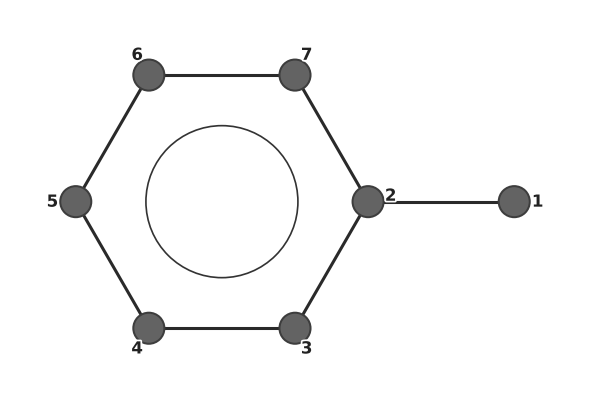

In [3]:
from synedu.Utils import print_graph_attributes
from synedu.Utils.conversion import smiles_to_graph
from synedu.Utils.vis import draw_molecular_graph

smiles = '[CH3:1][c:2]1[cH:3][cH:4][cH:5][cH:6][cH:7]1'
graph = smiles_to_graph(smiles, drop_non_aam=True, use_index_as_atom_map=True)
print_graph_attributes(graph)

draw_molecular_graph(graph, show_indices=True)

In [4]:
import networkx as nx
from collections import defaultdict
from typing import Any, Dict, Tuple, Set

Node = int
Attr = Dict[str, Any]
Adj = Dict[Node, Set[Node]]
BondOrder = Dict[Tuple[Node, Node], float]


def parse_graph_from_nx(
    G: nx.Graph,
    *,
    add_degree: bool = True,
    add_neighbors_ids: bool = True,
    default_bond_order: float = 1.0,
) -> Tuple[Dict[Node, Attr], Adj, BondOrder]:

    # --- nodes dict (copy attrs) ---
    nodes: Dict[Node, Attr] = {}
    for n, d in G.nodes(data=True):
        nodes[int(n)] = dict(d or {})

    # --- adjacency and bond orders ---
    adj: Adj = defaultdict(set)
    bond_order: BondOrder = {}

    if G.is_multigraph():
        # for multigraph, aggregate parallel edges (take max order)
        for u, v, key, ed in G.edges(keys=True, data=True):
            u_i, v_i = int(u), int(v)
            adj[u_i].add(v_i)
            adj[v_i].add(u_i)
            ord_val = ed.get("order", default_bond_order) if ed else default_bond_order
            try:
                ord_f = float(ord_val)
            except Exception:
                ord_f = default_bond_order
            # keep maximum order across parallel edges
            prev = bond_order.get((u_i, v_i), None)
            if prev is None or ord_f > prev:
                bond_order[(u_i, v_i)] = ord_f
                bond_order[(v_i, u_i)] = ord_f
    else:
        for u, v, ed in G.edges(data=True):
            u_i, v_i = int(u), int(v)
            adj[u_i].add(v_i)
            adj[v_i].add(u_i)
            ord_val = ed.get("order", default_bond_order) if ed else default_bond_order
            try:
                ord_f = float(ord_val)
            except Exception:
                ord_f = default_bond_order
            bond_order[(u_i, v_i)] = ord_f
            bond_order[(v_i, u_i)] = ord_f

    # ensure every node appears in adj (even if isolated)
    for n in list(nodes.keys()):
        adj.setdefault(n, set())

    # enrich node attrs with degree / neighbors_ids if requested
    if add_neighbors_ids or add_degree:
        for n in nodes:
            nbrs_sorted = sorted(adj.get(n, []))
            if add_neighbors_ids:
                nodes[n].setdefault("neighbors_ids", nbrs_sorted)
            if add_degree:
                nodes[n].setdefault("degree", len(nbrs_sorted))

    return nodes, dict(adj), bond_order

In [5]:
nodes, adj, bond_order = parse_graph_from_nx(graph)

In [6]:
from typing import DefaultDict
from typing import List

Partition = List[List[Node]]


def initial_partition_from_nodes(nodes: Dict[Node, Attr]) -> Partition:
    """
    Initial partition using only (element, aromatic, degree_from_neighbors_list).
    degree_from_neighbors_list = len(attr['neighbors'])
    """
    buckets: DefaultDict[Tuple[Any, ...], List[Node]] = defaultdict(list)

    for v in sorted(nodes):
        a = nodes[v]
        deg = len(a.get("neighbors", []))
        key = (a.get("element"), bool(a.get("aromatic")), deg)
        buckets[key].append(v)

    # deterministic ordering
    return [sorted(buckets[k]) for k in sorted(buckets.keys())]


P0 = initial_partition_from_nodes(nodes)
print("P0 (initial partition):")
for i, cell in enumerate(P0):
    print(f"  C{i}: {cell}")

P0 (initial partition):
  C0: [1]
  C1: [2, 3, 4, 5, 6, 7]


- **`C0: [1]` — methyl carbon (unique)**  
  Node `1` is a *non-aromatic carbon* with degree `1` (the methyl substituent). Its tuple `(element='C', aromatic=False, degree=1)` is unique in the graph, so it forms its own color class. 

- **`C2: [2]` — ipso aromatic carbon (unique)**  
  Node `2` is the *ipso* aromatic carbon (the ring carbon bonded to the methyl group) with degree `3`. The triple `(C, aromatic=True, degree=3)` differs from the ring CH positions, so it also forms its own class.

- **`C1: [3,4,5,6,7]` — remaining ring carbons (ambiguous)**  
  Nodes `3–7` are aromatic carbons with degree `2`, so the chosen attributes make them locally indistinguishable. WL groups them into one big class. These are the ring CH positions that, from the local viewpoint (element, aromatic flag, neighbor count), look the same while the global symmetry (reflections/rotations) determines which are actually interchangeable.


### 1.2 Refinement

The refinement operator $R(\Pi)$ returns the *coarsest equitable partition* that refines $\Pi$. A partition $\Pi=\{C_1,\dots,C_k\}$ is equitable iff for every pair of cells $C_i,C_j$ and every $u,v\in C_i$,
$$
|N(u)\cap C_j| \;=\; |N(v)\cap C_j|.
$$
Operationally we compute, for each vertex $v$, the signature
$$
\sigma(v) \;=\; \big(|N(v)\cap C_1|,\;|N(v)\cap C_2|,\;\dots,\;|N(v)\cap C_k|\big),
$$
and split cells by identical signatures until nothing splits.


**Chemical intuition**

- **Signature = local chemical context.**  
  The signature $\sigma(v)$ is a compact count-vector that records *how many* neighbors $v$ has in each *color class* (each class corresponds to a type of chemical environment defined so far). Chemically this is like saying: *“how many of my neighbors are methyl-like, ipso-like, aromatic-CH-like, etc.”* — not which exact atoms they are.

- **Splitting = discovering positional roles.**  
  When a cell $C$ splits into subcells, WL has discovered that atoms that looked the same under the current descriptors actually occupy *different positions* in the molecular graph (e.g., ortho vs. meta vs. para). Splitting is not an abstract algebraic trick — it corresponds to chemically meaningful distinctions (bonding pattern relative to substituents).

- **Equitable partition = indistinguishability under chosen observables.**  
  If a partition is equitable, then *within each cell* all atoms have identical counts of neighbors in every environment-class. That means *no additional local topological information* (based on current coloring) can tell those atoms apart; they are locally indistinguishable under the chosen invariants.


**Toluene example**

Start with an initial coloring by $(\text{element},\ \text{aromatic},\ \deg)$:

```text
C0 = [1] # methyl carbon (non-aromatic, deg=1)
C1 = [3,4,5,6,7] # ring CH positions (aromatic, deg=2)
C2 = [2] # ipso carbon (aromatic, deg=3)
```


Order cells as $(C_0,C_1,C_2)$. Compute signatures $\sigma(v)=(|N(v)\cap C_0|,|N(v)\cap C_1|,|N(v)\cap C_2|)$:

- $\sigma(3)=(0,1,1)$ because node 3 neighbors are $\{2,4\}$: one in $C_1$ (node 4) and one in $C_2$ (node 2).  
- $\sigma(4)=(0,2,0)$ because node 4 neighbors $\{3,5\}$ both lie in $C_1$.  
- $\sigma(5)=(0,2,0)$ (neighbors $\{4,6\}$).  
- $\sigma(6)=(0,2,0)$ (neighbors $\{5,7\}$).  
- $\sigma(7)=(0,1,1)$ (neighbors $\{6,2\}$).

So $C_1$ splits into two signature groups:
- $C_{1a}=[3,7]$ with $\sigma=(0,1,1)$ (these are *ortho* relative to the substituent), and  
- $C_{1b}=[4,5,6]$ with $\sigma=(0,2,0)$ (positions not directly adjacent to ipso).

Refine again using $[C_0,C_{1a},C_{1b},C_2]$:
- Within $C_{1b}$ the new signatures differentiate the para position (node 5) from its neighbors: $C_{1b}\to[4,6]$ and $[5]$.  

Final $R(\Pi)$ for this example:
```text
[[1], [3,7], [4,6], [5], [2]]
```


In [7]:
def refine(
    part: Partition, adj: Adj
) -> Tuple[Partition, bool, Dict[Node, Tuple[int, ...]]]:

    cell_of = {v: i for i, cell in enumerate(part) for v in cell}

    new_part: Partition = []
    changed = False
    sigs: Dict[Node, Tuple[int, ...]] = {}

    for cell in part:
        buckets = defaultdict(list)
        for v in cell:
            counts = []
            for j in range(len(part)):
                cnt = sum(1 for u in adj.get(v, ()) if cell_of[u] == j)
                counts.append(cnt)
            sig = tuple(counts)
            sigs[v] = sig
            buckets[sig].append(v)

        if len(buckets) == 1:
            new_part.append(sorted(cell))
        else:
            changed = True
            for sig in sorted(buckets.keys()):
                new_part.append(sorted(buckets[sig]))

    return new_part, changed, sigs

In [8]:
refine(P0, adj)

([[1], [3, 4, 5, 6, 7], [2]],
 True,
 {1: (0, 1), 2: (1, 2), 3: (0, 2), 4: (0, 2), 5: (0, 2), 6: (0, 2), 7: (0, 2)})

In [9]:
def refine_to_stable(part: Partition, adj: Adj, *, verbose: bool = True) -> Partition:
    """Repeat WL refinement until stable; print each iteration (simple)."""
    it = 0
    while True:
        it += 1
        part2, changed, sigs = refine(part, adj)

        if verbose:
            print(f"\nWL iter {it}")
            for v in sorted(sigs):
                print(f"  node {v}: sig={sigs[v]}")
            print("  partition:", part2)

        part = part2
        if not changed:
            return part

In [10]:
refine_partition = refine_to_stable(P0, adj)
refine_partition


WL iter 1
  node 1: sig=(0, 1)
  node 2: sig=(1, 2)
  node 3: sig=(0, 2)
  node 4: sig=(0, 2)
  node 5: sig=(0, 2)
  node 6: sig=(0, 2)
  node 7: sig=(0, 2)
  partition: [[1], [3, 4, 5, 6, 7], [2]]

WL iter 2
  node 1: sig=(0, 0, 1)
  node 2: sig=(1, 2, 0)
  node 3: sig=(0, 1, 1)
  node 4: sig=(0, 2, 0)
  node 5: sig=(0, 2, 0)
  node 6: sig=(0, 2, 0)
  node 7: sig=(0, 1, 1)
  partition: [[1], [3, 7], [4, 5, 6], [2]]

WL iter 3
  node 1: sig=(0, 0, 0, 1)
  node 2: sig=(1, 2, 0, 0)
  node 3: sig=(0, 0, 1, 1)
  node 4: sig=(0, 1, 1, 0)
  node 5: sig=(0, 0, 2, 0)
  node 6: sig=(0, 1, 1, 0)
  node 7: sig=(0, 0, 1, 1)
  partition: [[1], [3, 7], [5], [4, 6], [2]]

WL iter 4
  node 1: sig=(0, 0, 0, 0, 1)
  node 2: sig=(1, 2, 0, 0, 0)
  node 3: sig=(0, 0, 0, 1, 1)
  node 4: sig=(0, 1, 1, 0, 0)
  node 5: sig=(0, 0, 0, 2, 0)
  node 6: sig=(0, 1, 1, 0, 0)
  node 7: sig=(0, 0, 0, 1, 1)
  partition: [[1], [3, 7], [5], [4, 6], [2]]


[[1], [3, 7], [5], [4, 6], [2]]

### 1.3 WL refinement for chemical graphs

At each iteration replace each node’s color by  
`(old_color, sorted_multiset((neighbor_color, edge_label)))`, re-rank tuples lexicographically, stop when stable.

---

**Formal algorithm**

```text
Inputs:
  G = (V,E) with node attrs a_V(v) and edge attrs a_E(u,v)
  max_iter = 50

Initialize:
  color0(v) := tuple(a_V(v))                # base node signature
  map distinct color0 → integer ids (lexicographic)

For t = 0 .. max_iter-1:
  for each v in V:
    neigh_sig := sorted([ ( color_t(u), a_E(v,u) ) for u in N(v) ])
    sig_v := ( color_t(v), tuple(neigh_sig) )
  rank distinct sig_v lexicographically → color_{t+1}(v)
  if color_{t+1} == color_t for all v: break

Output:
  partition := classes of nodes with equal final color
  colors := mapping node → final color id
```

**Chemical intuition**

- Base color = atom identity (element, aromatic flag, H-count, charge, …).

- Refinement = who you are connected to and how (neighbor color + bond label).

- Result = an *equitable* partition: atoms in same class are locally indistinguishable under chosen features.

- Use as: orbit approximation, node features for ML, seed for exact automorphism.

**Toluene**

```text
              3
            /   \
          4       2 --1
          |       |
          5       7
            \   /
              6
```

**t = 0 — initial signatures (by node attrs)**

- `s0(1) = (C, False, h=3)`  → **color A**  — methyl (unique)  
- `s0(2) = (C, True,  h=0)`  → **color B**  — ipso (unique)  
- `s0(3,4,5,6,7) = (C, True, h=1)` → **color C**  — ring carbons (initially same)

---

**t = 1 — incorporate neighbor signatures**

- `sig(1) = (A, [ (B,1.0) ])`                      → `{1}`  
- `sig(2) = (B, [ (A,1.0),(C,1.5),(C,1.5) ])`      → `{2}`  
- `sig(3) = (C, [ (B,1.5),(C,1.5) ])`              → `{3,7}`  
- `sig(4) = (C, [ (C,1.5),(C,1.5) ])`              → `{4,5,6}`  

**Partition after t = 1:** `{1}, {2}, {3,7}, {4,5,6}`

---

**t = 2 — refine within ring classes**

Using t=1 colors, neighbors of `{4,5,6}` differ → split:  
**New partition:** `{1}, {2}, {3,7}, {4,6}, {5}`

---

**t = 3 — stable (no further splits)**

**Final partition:**

- `{1}` — methyl (CH₃)  
- `{2}` — ipso (attached to methyl)  
- `{3,7}` — ortho carbons (equivalent)  
- `{4,6}` — meta carbons (equivalent)  
- `{5}` — para carbon (unique)


#### WL refinement iteration strip

Each column shows the partition class (colour) assigned to each node at one WL iteration. Nodes with the same colour are in the same equivalence class at that step. As refinement proceeds, symmetric atoms split into finer classes until the partition is **stable** (no cell changes between two consecutive columns). Atoms that remain in the same class throughout are **WL-indistinguishable**.

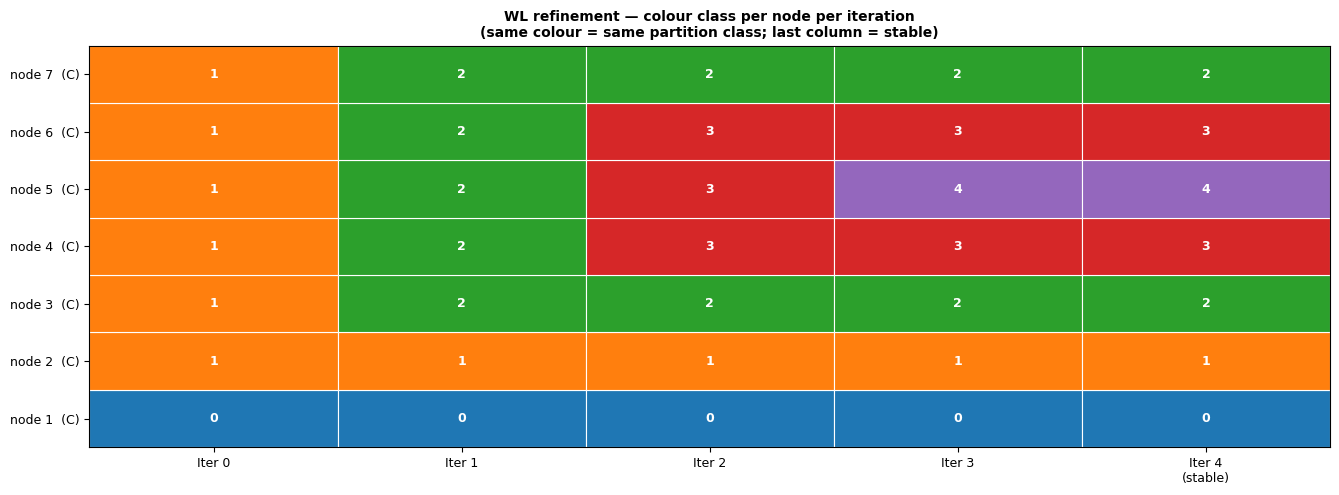

In [11]:
import copy
import numpy as np
import matplotlib.pyplot as plt

# Replay WL refinement and store partition at each iteration
_part = copy.deepcopy(P0)
_history = [copy.deepcopy(_part)]
for _ in range(20):
    _new, _changed, _ = refine(_part, adj)
    _history.append(copy.deepcopy(_new))
    _part = _new
    if not _changed:
        break

_all_nodes = sorted({n for cell in P0 for n in cell})
_n_nodes = len(_all_nodes)
_n_iters = len(_history)
_node_row = {n: i for i, n in enumerate(_all_nodes)}

_grid = np.zeros((_n_nodes, _n_iters), dtype=int)
for col, part in enumerate(_history):
    for ci, cell in enumerate(sorted(part, key=min)):
        for n in cell:
            _grid[_node_row[n], col] = ci

_cmap = plt.cm.tab10
fig, ax = plt.subplots(figsize=(2.5 * _n_iters + 1, 0.55 * _n_nodes + 1.2))

for r in range(_n_nodes):
    for c in range(_n_iters):
        val = _grid[r, c]
        color = _cmap(val % 10)
        rect = plt.Rectangle((c, r), 1, 1, color=color, ec="white", lw=0.8)
        ax.add_patch(rect)
        ax.text(
            c + 0.5,
            r + 0.5,
            str(val),
            ha="center",
            va="center",
            fontsize=9,
            color="white",
            fontweight="bold",
        )

ax.set_xlim(0, _n_iters)
ax.set_ylim(0, _n_nodes)
ax.set_xticks([i + 0.5 for i in range(_n_iters)])
_iter_labels = [
    f"Iter {i}" if i < _n_iters - 1 else f"Iter {i}\n(stable)" for i in range(_n_iters)
]
ax.set_xticklabels(_iter_labels, fontsize=9)
ax.set_yticks([i + 0.5 for i in range(_n_nodes)])
_node_lbl = [f"node {n}  ({graph.nodes[n].get('element','?')})" for n in _all_nodes]
ax.set_yticklabels(_node_lbl, fontsize=9)
ax.set_title(
    "WL refinement — colour class per node per iteration\n"
    "(same colour = same partition class; last column = stable)",
    fontsize=10,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

**Figure — WL coloring progression on toluene.**  
Each panel shows the graph after one refinement step. Nodes with the same colour share the same partition class (WL-indistinguishable at that iteration). Iteration 0 is the initial partition by element type; the partition stabilises once no cell splits further.

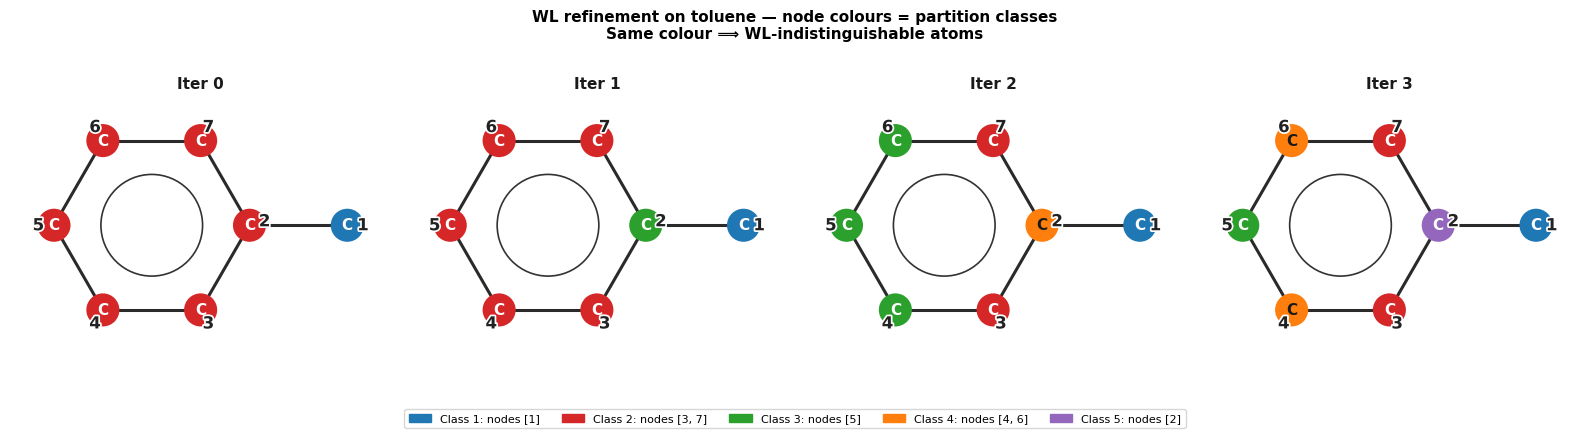

Stable partition (5 classes) reached after 4 iteration(s).


In [11]:
import copy
import matplotlib.pyplot as plt
from synedu.Utils.vis import draw_molecular_graph, _layout_from_graph_mol

_smi_tol = 'Cc1ccccc1'
_g_tol = smiles_to_graph(_smi_tol)
_nodes_tol, _adj_tol, _ = parse_graph_from_nx(_g_tol)
_P0_tol = initial_partition_from_nodes(_nodes_tol)

# Run WL refinement and record partition at every step
_part_tol = copy.deepcopy(_P0_tol)
_wl_history = [copy.deepcopy(_part_tol)]
for _ in range(10):
    _new, _changed, _ = refine(_part_tol, _adj_tol)
    _wl_history.append(copy.deepcopy(_new))
    _part_tol = _new
    if not _changed:
        break

_PALETTE = [
    "#1F77B4",
    "#D62728",
    "#2CA02C",
    "#FF7F0E",
    "#9467BD",
    "#8C564B",
    "#E377C2",
    "#17BECF",
]

# Build per-iteration node→colour mapping
_iter_node_colors = []
for _part in _wl_history:
    _nc = {}
    for _ci, _cell in enumerate(_part):
        for _n in _cell:
            _nc[_n] = _PALETTE[_ci % len(_PALETTE)]
    _iter_node_colors.append(_nc)

_n_show = min(len(_wl_history), 4)
fig, axes = plt.subplots(1, _n_show, figsize=(_n_show * 4, 4), facecolor="white")
if _n_show == 1:
    axes = [axes]

for k in range(_n_show):
    _stable = k == len(_wl_history) - 1
    draw_molecular_graph(
        _g_tol,
        ax=axes[k],
        custom_node_colors=_iter_node_colors[k],
        label_mode="all",
        show_indices=True,
        title=f"Iter {k}{'  (stable)' if _stable else ''}",
    )

# Legend: colour → partition class at final stable iteration
import matplotlib.patches as mpatches

_final_part = _wl_history[-1]
_patches = [
    mpatches.Patch(
        color=_PALETTE[i % len(_PALETTE)], label=f"Class {i+1}: nodes {sorted(_cell)}"
    )
    for i, _cell in enumerate(_final_part)
]
fig.legend(
    handles=_patches,
    loc="lower center",
    ncol=len(_patches),
    fontsize=8,
    frameon=True,
    bbox_to_anchor=(0.5, -0.08),
)

fig.suptitle(
    "WL refinement on toluene — node colours = partition classes\n"
    "Same colour ⟹ WL-indistinguishable atoms",
    fontsize=11,
    fontweight="bold",
)
plt.tight_layout()
plt.show()
print(
    f"Stable partition ({len(_final_part)} classes) reached after "
    f"{len(_wl_history)-1} iteration(s)."
)

#### WL cell count convergence across molecules

More symmetric molecules need fewer iterations to reach a stable partition
(benzene stabilizes early because all carbons are equivalent).
Less symmetric molecules keep splitting cells for more iterations.



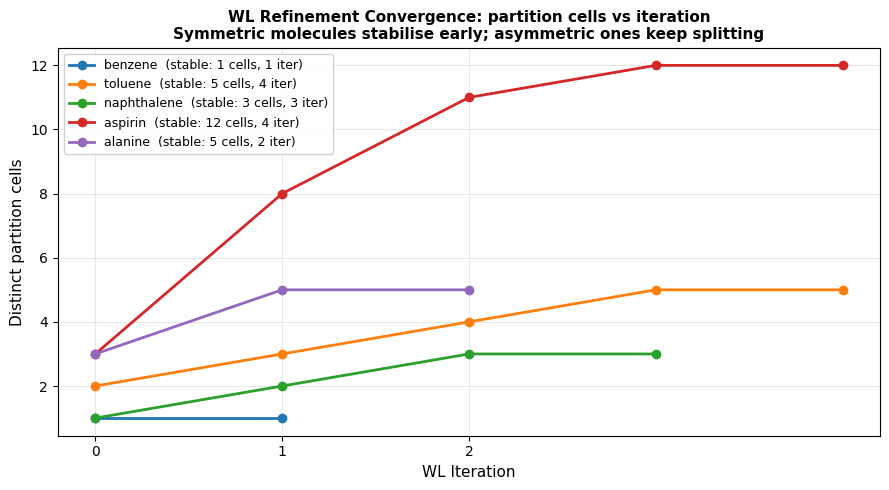

In [12]:
import matplotlib.pyplot as plt
import copy
from synedu.Utils import smiles_to_graph

_MOLECULES = [
    ('benzene', 'c1ccccc1'),
    ('toluene', 'Cc1ccccc1'),
    ('naphthalene', 'c1ccc2ccccc2c1'),
    ('aspirin', 'CC(=O)Oc1ccccc1C(=O)O'),
    ('alanine', 'N[C@@H](C)C(=O)O'),
]

fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for color, (name, smi) in zip(colors, _MOLECULES):
    try:
        g = smiles_to_graph(smi)
        nodes, adj, _ = parse_graph_from_nx(g)
        _part = initial_partition_from_nodes(nodes)  # List[List[Node]] ✓
        history = [len(_part)]
        for _ in range(30):
            _new, _changed, _ = refine(_part, adj)
            history.append(len(_new))
            _part = _new
            if not _changed:
                break
        ax.plot(
            range(len(history)),
            history,
            'o-',
            color=color,
            linewidth=2,
            markersize=6,
            label=f'{name}  (stable: {history[-1]} cells, {len(history)-1} iter)',
        )
    except Exception as exc:
        print(f'{name}: {exc}')

ax.set_xlabel('WL Iteration', fontsize=11)
ax.set_ylabel('Distinct partition cells', fontsize=11)
ax.set_title(
    'WL Refinement Convergence: partition cells vs iteration\n'
    'Symmetric molecules stabilise early; asymmetric ones keep splitting',
    fontsize=11,
    fontweight='bold',
)
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(alpha=0.3)
ax.set_xticks(range(max(2, max(len([1] * 3) for _ in _MOLECULES))))  # at least 0..2
plt.tight_layout()
plt.show()

In [13]:
from collections import defaultdict
from typing import Dict, Hashable, List, Sequence, Tuple
import networkx as nx

Node = Hashable
Partition = List[List[Node]]


def wl1_partition_nx(
    G: nx.Graph,
    node_attrs: Sequence[str] = ("element", "aromatic", "charge", "hcount"),
    edge_attrs: Sequence[str] = ("order",),
    max_iter: int = 50,
) -> Tuple[Partition, Dict[Node, int]]:
    """
    Deterministic WL-1 color refinement for labeled NetworkX graphs.
    """

    # --- initial colors: group by node attributes ---
    sig0 = {v: tuple(G.nodes[v].get(k) for k in node_attrs) for v in G.nodes()}
    uniq = sorted(set(sig0.values()))
    rank = {s: i for i, s in enumerate(uniq)}
    colors = {v: rank[sig0[v]] for v in G.nodes()}

    # --- WL refinement ---
    for _ in range(max_iter):
        sig = {}
        for v in G.nodes():
            nbr = sorted(
                (colors[u], tuple(G.edges[v, u].get(k) for k in edge_attrs))
                for u in G.neighbors(v)
            )
            sig[v] = (colors[v], tuple(nbr))

        uniq = sorted(set(sig.values()))
        rank = {s: i for i, s in enumerate(uniq)}
        new_colors = {v: rank[sig[v]] for v in G.nodes()}

        if new_colors == colors:
            break
        colors = new_colors

    # --- build partition ---
    buckets = defaultdict(list)
    for v, c in colors.items():
        buckets[c].append(v)

    partition = [sorted(nodes) for _, nodes in sorted(buckets.items())]
    return partition, colors


wl_partition, wl_colors = wl1_partition_nx(graph)
print("WL-labeled stable partition:", wl_partition)

WL-labeled stable partition: [[1], [2], [3, 7], [4, 6], [5]]


### 1.4. Approximation

Now we have the **stable WL partition** which is obtained after Weisfeiler–Lehman (WL) color refinement converges.
Each inner list represents a color class, i.e. a set of nodes that WL cannot
distinguish further based on their attributes and local neighborhoods.

In the toluene example, this partition already has a clear chemical meaning:
the methyl carbon, the ipso carbon, the para position, and two symmetric pairs
(ortho and meta positions).

From the partition above, a WL-consistent block ordering may be written as

```text
[1, (3,7), 5, (4,6), 2]
```

Only the two parenthesized blocks are ambiguous. Enumerating their internal
permutations yields \(2! \times 2! = 4\) candidate linearizations. Evaluating
all of them and selecting the lexicographically smallest graph signature
produces a canonical index that is strictly stronger than plain WL
canonicalization, while remaining inexpensive.

This approach is **not a full automorphism solver**, but a WL-seeded,
locally exact approximation that is well sui

In [14]:
def adjacency_signature(G, order):
    """
    Serialize a labeled graph into a lexicographically comparable signature.

    Parameters
    ----------
    G : Graph
        Labeled graph with node and edge attributes.
    order : list[int]
        Node ordering to be evaluated.

    Returns
    -------
    tuple
        Lexicographically comparable adjacency signature.
    """

    # 1. node attribute signatures
    node_sig = tuple(
        (
            G.nodes[v]["element"],
            G.nodes[v]["aromatic"],
            G.nodes[v].get("charge", 0),
            G.nodes[v].get("hcount", 0),
        )
        for v in order
    )

    # 2. adjacency / edge signatures (upper triangular)
    edge_sig = []
    for i, u in enumerate(order):
        for v in order[i + 1 :]:
            if G.has_edge(u, v):
                edge_sig.append(G.edges[u, v].get("order", 1))
            else:
                edge_sig.append(0)

    return (node_sig, tuple(edge_sig))

In [15]:
from itertools import permutations, product


def wl_approx_canonical_index(G, wl_partition):
    """
    WL-consistent canonicalization:
    - preserve WL cell order
    - permute only inside cells
    - choose lexicographically minimal adjacency signature
    """

    choices = []
    for cell in wl_partition:
        if len(cell) == 1:
            choices.append([tuple(cell)])
        else:
            choices.append(list(permutations(cell)))
    best_sig = None
    best_order = None

    for picked in product(*choices):
        order = [v for block in picked for v in block]
        sig = adjacency_signature(G, order)

        if best_sig is None or sig < best_sig:
            best_sig = sig
            best_order = order

    return best_order

In [16]:
best_order = wl_approx_canonical_index(graph, refine_partition)
best_order

[1, 3, 7, 5, 6, 4, 2]

In [17]:
import networkx as nx


def reindex_graph_with_atom_map(G, best_order):
    """
    Create a canonical copy of a graph using a given node order.
    Nodes are relabeled to 1..N following best_order, and atom_map
    is reassigned accordingly.

    Parameters
    ----------
    G : nx.Graph
        Original graph.
    best_order : list
        Canonical node ordering (list of original node ids).

    Returns
    -------
    nx.Graph
        New graph with canonical node indices and atom_map labels.
    """

    # mapping: old_node -> new_index (1-based, SMILES-style)
    relabel = {old: i + 1 for i, old in enumerate(best_order)}

    # create a fresh graph of the same type
    H = G.__class__()

    # add nodes in canonical order
    for old in best_order:
        new = relabel[old]
        attrs = dict(G.nodes[old])
        attrs["atom_map"] = new  # overwrite atom_map
        H.add_node(new, **attrs)

    # add edges with attributes
    for u, v, edata in G.edges(data=True):
        if u in relabel and v in relabel:
            H.add_edge(relabel[u], relabel[v], **dict(edata))

    return H


wl_canon = reindex_graph_with_atom_map(graph, best_order)
print_graph_attributes(wl_canon)

🔹 Nodes and their attributes:
  Node 1: {'element': 'C', 'formal_charge': 0, 'aromatic': False, 'hcount': 3, 'atom_map': 1, 'rdkit_idx': 0}
  Node 2: {'element': 'C', 'formal_charge': 0, 'aromatic': True, 'hcount': 1, 'atom_map': 2, 'rdkit_idx': 2}
  Node 3: {'element': 'C', 'formal_charge': 0, 'aromatic': True, 'hcount': 1, 'atom_map': 3, 'rdkit_idx': 6}
  Node 4: {'element': 'C', 'formal_charge': 0, 'aromatic': True, 'hcount': 1, 'atom_map': 4, 'rdkit_idx': 4}
  Node 5: {'element': 'C', 'formal_charge': 0, 'aromatic': True, 'hcount': 1, 'atom_map': 5, 'rdkit_idx': 5}
  Node 6: {'element': 'C', 'formal_charge': 0, 'aromatic': True, 'hcount': 1, 'atom_map': 6, 'rdkit_idx': 3}
  Node 7: {'element': 'C', 'formal_charge': 0, 'aromatic': True, 'hcount': 0, 'atom_map': 7, 'rdkit_idx': 1}

🔸 Edges and their attributes:
  Edge 1-7: {'order': 1.0, 'aromatic': False}
  Edge 2-7: {'order': 1.5, 'aromatic': True}
  Edge 2-6: {'order': 1.5, 'aromatic': True}
  Edge 3-7: {'order': 1.5, 'aromatic': 

## 2. Individualization, Refinement, and Exact Methods

- **Individualization**: for $v\in C$ write $I_v(\Pi)$ for the partition obtained by replacing $C$ with $\{v\}$ and $C\setminus\{v\}$.
- The **IR search tree** has nodes (partitions) and children of a node $\Pi$ given by $R(I_v(\Pi))$ for chosen $v$ in a non-singleton cell.
- During IR Nauty discovers automorphisms $\sigma\in\operatorname{Aut}(G)$ and stores a generating set $\mathcal{G}$. If a discovered $\sigma$ maps a search node to an already visited node, Nauty **prunes** that branch.

In [18]:
from typing import List

Partition = List[List[int]]


def individualize(part: Partition, cell_idx: int, v: int) -> Partition:
    """
    Individualize node v inside part[cell_idx].

    Split:
        C -> [v], [C \\ {v}]
    while keeping partition order stable.

    Parameters
    ----------
    part : Partition
        Current WL-stable partition.
    cell_idx : int
        Index of the cell to individualize.
    v : int
        Node to individualize.

    Returns
    -------
    Partition
        New partition with v individualized.
    """
    C = part[cell_idx]
    assert v in C and len(C) > 1

    new_part: Partition = []
    for i, cell in enumerate(part):
        if i != cell_idx:
            new_part.append(cell)
        else:
            new_part.append([v])
            rest = [u for u in cell if u != v]
            if rest:
                new_part.append(rest)

    return new_part

In [19]:
def individualize_and_refine(part: Partition, adj):
    """
    Perform one level of nauty-style individualization:
    - pick the first non-singleton cell
    - branch on each choice
    - WL-refine each branch to stability
    """
    # find first non-singleton cell
    for i, cell in enumerate(part):
        if len(cell) > 1:
            cell_idx = i
            break
    else:
        return []  # already discrete

    branches = []

    for v in cell:
        part_i = individualize(part, cell_idx, v)
        part_i = refine_to_stable(part_i, adj, verbose=False)
        branches.append(part_i)

    return branches

In [20]:
branches = individualize_and_refine(wl_partition, adj)

for i, p in enumerate(branches, 1):
    print(f"Branch {i}: {p}")

Branch 1: [[1], [2], [3], [7], [6], [4], [5]]
Branch 2: [[1], [2], [7], [3], [6], [4], [5]]


In [21]:
def _candidate_search(part: Partition, adj):
    """
    Generate all fully discrete partitions reachable by
    individualization + WL refinement.
    """
    stack = [part]
    leaves = []

    while stack:
        P = stack.pop()

        # check if discrete
        if all(len(cell) == 1 for cell in P):
            leaves.append(P)
            continue

        branches = individualize_and_refine(P, adj)
        stack.extend(branches)

    return leaves


leaves = _candidate_search(wl_partition, adj)
leaves

[[[1], [2], [7], [3], [6], [4], [5]], [[1], [2], [3], [7], [6], [4], [5]]]

In [22]:
def canonical_by_ir(G, part, adj):
    leaves = _candidate_search(part, adj)

    best_sig = None
    best_order = None

    for P in leaves:
        order = [cell[0] for cell in P]
        sig = adjacency_signature(G, order)

        if best_sig is None or sig < best_sig:
            best_sig = sig
            best_order = order

    return best_order


ir_order = canonical_by_ir(graph, refine_partition, adj)
print(ir_order)

[1, 3, 7, 5, 6, 4, 2]


**Individualization-Refinement (IR) search tree**

When the stable WL partition $\mathcal{P}^*$ is not fully discrete, we use
*individualization*: pick one ambiguous vertex, fix its color, then refine again.
This creates a binary tree of partition states; the canonical ordering
is the leaf with the lexicographically smallest certificate.

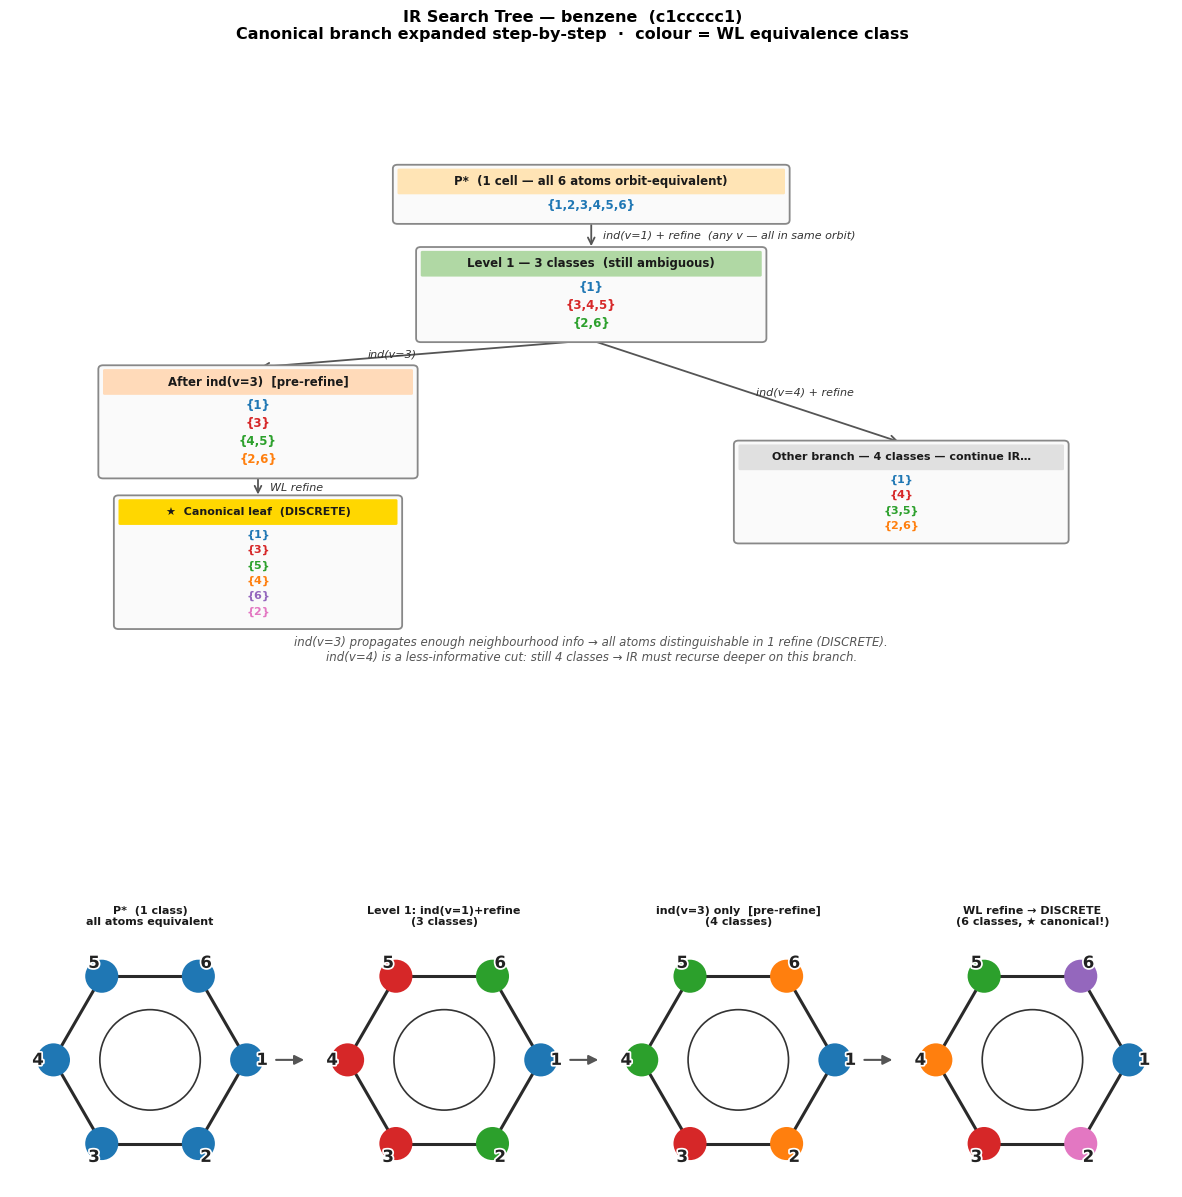

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from synedu.Utils import smiles_to_graph
from synedu.Utils.vis import draw_molecular_graph

# ── Palette and helpers ───────────────────────────────────────────────────
_PAL = ['#1F77B4', '#D62728', '#2CA02C', '#FF7F0E', '#9467BD', '#E377C2', '#17BECF']


def _do_ind_refine(part, adj, cell_idx, node):
    """Individualize node, then run one WL refine step."""
    ind = []
    for i, c in enumerate(part):
        if i == cell_idx:
            ind.append([node])
            rest = [n for n in c if n != node]
            if rest:
                ind.append(rest)
        else:
            ind.append(list(c))
    refined, _, _ = refine(ind, adj)
    return ind, refined


def _part_to_colors(part):
    return {n: _PAL[ci % len(_PAL)] for ci, cell in enumerate(part) for n in cell}


# ── Compute IR states for benzene ─────────────────────────────────────────
_smi = 'c1ccccc1'
_g = smiles_to_graph(_smi)
_ns, _adj, _ = parse_graph_from_nx(_g)
_Pstar = refine_to_stable(initial_partition_from_nodes(_ns), _adj, verbose=False)

_v0 = sorted(_Pstar[0])[0]
_l1_ind, _l1_ref = _do_ind_refine(_Pstar, _adj, 0, _v0)

_l2_ai = next(i for i, c in enumerate(_l1_ref) if len(c) > 1)
_l2all = sorted(_l1_ref[_l2_ai])
_va, _vb = _l2all[0], _l2all[1]

# Canonical branch: show ind THEN refine as two separate steps
_l2a_ind, _l2a_ref = _do_ind_refine(_l1_ref, _adj, _l2_ai, _va)

# Other branch: combined (may or may not reach discrete)
_l2b_ind, _l2b_ref = _do_ind_refine(_l1_ref, _adj, _l2_ai, _vb)

_l2a_disc = all(len(c) == 1 for c in _l2a_ref)
_l2b_disc = all(len(c) == 1 for c in _l2b_ref)

# ── Figure ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 14), facecolor='white')
fig.suptitle(
    'IR Search Tree — benzene  (c1ccccc1)\n'
    'Canonical branch expanded step-by-step  ·  colour = WL equivalence class',
    fontsize=11.5,
    fontweight='bold',
)
gs = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1.9, 1], hspace=0.22)

ax_t = fig.add_subplot(gs[0])
ax_t.set_xlim(0, 15)
ax_t.set_ylim(-0.4, 9.5)
ax_t.set_axis_off()

TITLE_H = 0.38


def _bh(part, row_h=0.28):
    return TITLE_H + len(part) * row_h + 0.14


def _draw_node(ax, cx, cy, header, part, hdr_col, w=3.8, row_h=0.28, fsize=8.5):
    bh = _bh(part, row_h)
    ax.add_patch(
        mpatches.FancyBboxPatch(
            (cx - w / 2, cy - bh / 2),
            w,
            bh,
            boxstyle='round,pad=0.06',
            fc='#FAFAFA',
            ec='#888',
            lw=1.3,
            zorder=3,
        )
    )
    ax.add_patch(
        mpatches.FancyBboxPatch(
            (cx - w / 2 + 0.02, cy + bh / 2 - TITLE_H),
            w - 0.04,
            TITLE_H - 0.02,
            boxstyle='round,pad=0.02',
            fc=hdr_col,
            ec='none',
            lw=0,
            zorder=4,
        )
    )
    ax.text(
        cx,
        cy + bh / 2 - TITLE_H / 2,
        header,
        ha='center',
        va='center',
        fontsize=fsize,
        fontweight='bold',
        color='#1a1a1a',
        zorder=5,
    )
    y = cy + bh / 2 - TITLE_H - row_h / 2 - 0.04
    for ci, cell in enumerate(part):
        col = _PAL[ci % len(_PAL)]
        txt = '{' + ','.join(str(n) for n in sorted(cell)) + '}'
        ax.text(
            cx,
            y,
            txt,
            ha='center',
            va='center',
            fontsize=fsize,
            color=col,
            fontweight='bold',
            zorder=5,
        )
        y -= row_h


def _arr(ax, x1, y1, x2, y2, lbl='', dx=0.15, ha='left', dy=0.0):
    ax.annotate(
        '',
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle='->', color='#555', lw=1.3, mutation_scale=12),
        zorder=2,
    )
    if lbl:
        mx = (x1 + x2) / 2 + dx
        my = (y1 + y2) / 2 + dy
        ax.text(
            mx,
            my,
            lbl,
            fontsize=8,
            color='#333',
            ha=ha,
            va='center',
            style='italic',
            zorder=5,
        )


# ── Tree positions ────────────────────────────────────────────────────────
X0, XA, XB = 7.5, 3.2, 11.5
BH0 = _bh(_Pstar)
BH1 = _bh(_l1_ref)
BH2a = _bh(_l2a_ind)
BH3a = _bh(_l2a_ref, row_h=0.24)
BH2b = _bh(_l2b_ref, row_h=0.24)
GAP = 0.48

Y0 = 8.8
Y1 = Y0 - BH0 / 2 - GAP - BH1 / 2
Y2a = Y1 - BH1 / 2 - GAP - BH2a / 2  # canonical: after ind (pre-refine)
Y3a = Y2a - BH2a / 2 - GAP * 0.8 - BH3a / 2  # canonical: after refine (leaf)
Y2b = (Y2a + Y3a) / 2  # other branch: combined ind+refine

# ── Root ─────────────────────────────────────────────────────────────────
_draw_node(
    ax_t,
    X0,
    Y0,
    f'P*  ({len(_Pstar)} cell — all {len(_ns)} atoms orbit-equivalent)',
    _Pstar,
    '#FFE4B5',
    w=5.0,
)

_arr(
    ax_t,
    X0,
    Y0 - BH0 / 2 - 0.03,
    X0,
    Y1 + BH1 / 2 + 0.03,
    f'ind(v={_v0}) + refine  (any v — all in same orbit)',
)

# ── Level 1 ──────────────────────────────────────────────────────────────
_draw_node(
    ax_t,
    X0,
    Y1,
    f'Level 1 — {len(_l1_ref)} classes  (still ambiguous)',
    _l1_ref,
    '#B0D8A4',
    w=4.4,
)

# ── Canonical branch: ind ONLY ───────────────────────────────────────────
_arr(
    ax_t,
    X0,
    Y1 - BH1 / 2 - 0.03,
    XA,
    Y2a + BH2a / 2 + 0.03,
    f'ind(v={_va})',
    dx=-0.1,
    ha='right',
)

_draw_node(
    ax_t, XA, Y2a, f'After ind(v={_va})  [pre-refine]', _l2a_ind, '#FFDAB9', w=4.0
)  # peach

# ── Canonical branch: refine → leaf ──────────────────────────────────────
_arr(ax_t, XA, Y2a - BH2a / 2 - 0.03, XA, Y3a + BH3a / 2 + 0.03, 'WL refine')

_l2a_hdr = '★  Canonical leaf  (DISCRETE)' if _l2a_disc else '★  Continue IR…'
_draw_node(
    ax_t,
    XA,
    Y3a,
    _l2a_hdr,
    _l2a_ref,
    '#FFD700' if _l2a_disc else '#AEC6E8',
    w=3.6,
    row_h=0.24,
    fsize=8,
)

# ── Other branch: combined ind+refine ────────────────────────────────────
_arr(
    ax_t,
    X0,
    Y1 - BH1 / 2 - 0.03,
    XB,
    Y2b + BH2b / 2 + 0.03,
    f'ind(v={_vb}) + refine',
    dx=0.12,
    ha='left',
)

_l2b_status = 'DISCRETE' if _l2b_disc else f'{len(_l2b_ref)} classes — continue IR…'
_draw_node(
    ax_t,
    XB,
    Y2b,
    f'Other branch — {_l2b_status}',
    _l2b_ref,
    '#FFD700' if _l2b_disc else '#E0E0E0',
    w=4.2,
    row_h=0.24,
    fsize=8,
)

# ── Explanatory note ─────────────────────────────────────────────────────
note_y = min(Y3a - BH3a / 2, Y2b - BH2b / 2) - 0.15
if _l2a_disc and not _l2b_disc:
    note = (
        f'ind(v={_va}) propagates enough neighbourhood info → all atoms distinguishable in 1 refine (DISCRETE).\n'
        f'ind(v={_vb}) is a less-informative cut: still {len(_l2b_ref)} classes → IR must recurse deeper on this branch.'
    )
elif _l2a_disc and _l2b_disc:
    note = 'Both branches reach a discrete leaf. IR picks the lexicographically smallest canonical certificate.'
else:
    note = 'Neither branch is yet discrete — IR recurses deeper on both.'
ax_t.text(
    7.5, note_y, note, ha='center', va='top', fontsize=8.5, color='#555', style='italic'
)

# ── Bottom: canonical path step-by-step ──────────────────────────────────
gs_b = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs[1], wspace=0.05)
_panels = [
    (f'P*  ({len(_Pstar)} class)\nall atoms equivalent', _part_to_colors(_Pstar)),
    (
        f'Level 1: ind(v={_v0})+refine\n({len(_l1_ref)} classes)',
        _part_to_colors(_l1_ref),
    ),
    (
        f'ind(v={_va}) only  [pre-refine]\n({len(_l2a_ind)} classes)',
        _part_to_colors(_l2a_ind),
    ),
    (
        f'WL refine → DISCRETE\n({len(_l2a_ref)} classes, ★ canonical!)',
        _part_to_colors(_l2a_ref),
    ),
]
for col, (ttl, cols) in enumerate(_panels):
    ax_g = fig.add_subplot(gs_b[col])
    draw_molecular_graph(
        _g,
        ax=ax_g,
        custom_node_colors=cols,
        label_mode='none',
        show_indices=True,
        title=ttl,
        title_fontsize=8,
    )
    if col < 3:
        ax_g.annotate(
            '',
            xy=(1.06, 0.5),
            xytext=(0.94, 0.5),
            xycoords='axes fraction',
            textcoords='axes fraction',
            arrowprops=dict(arrowstyle='-|>', color='#555', lw=1.5, mutation_scale=14),
        )
plt.show()

**Individualization depth across molecules**

After WL stabilises, the number of **non-singleton cells** tells us
how many atoms remain ambiguous — and therefore how many individualisation
steps the IR tree needs.  
Highly symmetric molecules (benzene) need the deepest tree;
fully asymmetric ones (alanine) need none at all.


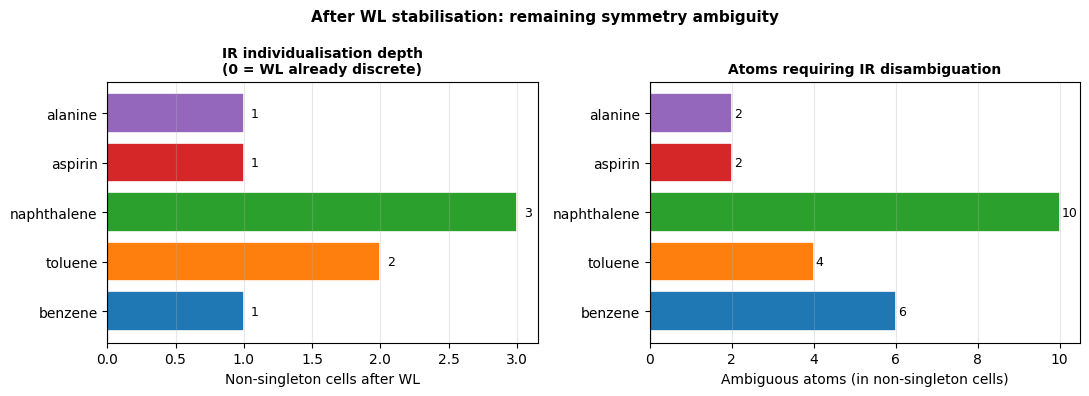


Summary:
  benzene     : 1 IR cell(s), 6 ambiguous atom(s)
  toluene     : 2 IR cell(s), 4 ambiguous atom(s)
  naphthalene : 3 IR cell(s), 10 ambiguous atom(s)
  aspirin     : 1 IR cell(s), 2 ambiguous atom(s)
  alanine     : 1 IR cell(s), 2 ambiguous atom(s)


In [24]:
import matplotlib.pyplot as plt
from synedu.Utils import smiles_to_graph

_MOLECULES = [
    ('benzene', 'c1ccccc1'),
    ('toluene', 'Cc1ccccc1'),
    ('naphthalene', 'c1ccc2ccccc2c1'),
    ('aspirin', 'CC(=O)Oc1ccccc1C(=O)O'),
    ('alanine', 'N[C@@H](C)C(=O)O'),
]

_results = []
for name, smi in _MOLECULES:
    g = smiles_to_graph(smi)
    nodes, adj, _ = parse_graph_from_nx(g)
    P0 = initial_partition_from_nodes(nodes)
    final = refine_to_stable(P0, adj, verbose=False)
    n_total = sum(len(c) for c in final)
    n_nonsingle = sum(1 for c in final if len(c) > 1)  # cells needing IR
    n_ambig = sum(len(c) for c in final if len(c) > 1)  # ambiguous atoms
    _results.append((name, n_nonsingle, n_ambig, n_total))

names = [r[0] for r in _results]
n_ir = [r[1] for r in _results]
n_amb = [r[2] for r in _results]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), facecolor='white')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

axes[0].barh(names, n_ir, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_xlabel('Non-singleton cells after WL', fontsize=10)
axes[0].set_title(
    'IR individualisation depth\n(0 = WL already discrete)',
    fontsize=10,
    fontweight='bold',
)
axes[0].axvline(0, color='#333', lw=0.8)
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(n_ir):
    axes[0].text(v + 0.05, i, str(v), va='center', fontsize=9)

axes[1].barh(names, n_amb, color=colors, edgecolor='white', linewidth=1.2)
axes[1].set_xlabel('Ambiguous atoms (in non-singleton cells)', fontsize=10)
axes[1].set_title('Atoms requiring IR disambiguation', fontsize=10, fontweight='bold')
axes[1].axvline(0, color='#333', lw=0.8)
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(n_amb):
    axes[1].text(v + 0.05, i, str(v), va='center', fontsize=9)

fig.suptitle(
    'After WL stabilisation: remaining symmetry ambiguity',
    fontsize=11,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

print('\nSummary:')
for name, n_ir_, n_amb_, n_tot in _results:
    status = (
        'discrete (no IR needed)'
        if n_ir_ == 0
        else f'{n_ir_} IR cell(s), {n_amb_} ambiguous atom(s)'
    )
    print(f'  {name:12s}: {status}')

## 3. Atom-Mapped Canonicalization

Canonical atom-map numbering follows the same motivation as canonical molecular descriptions: equivalent structures should receive deterministic identifiers before comparison [\[3\]](#6.-References), [\[5\]](#6.-References).

Now we combine all of them

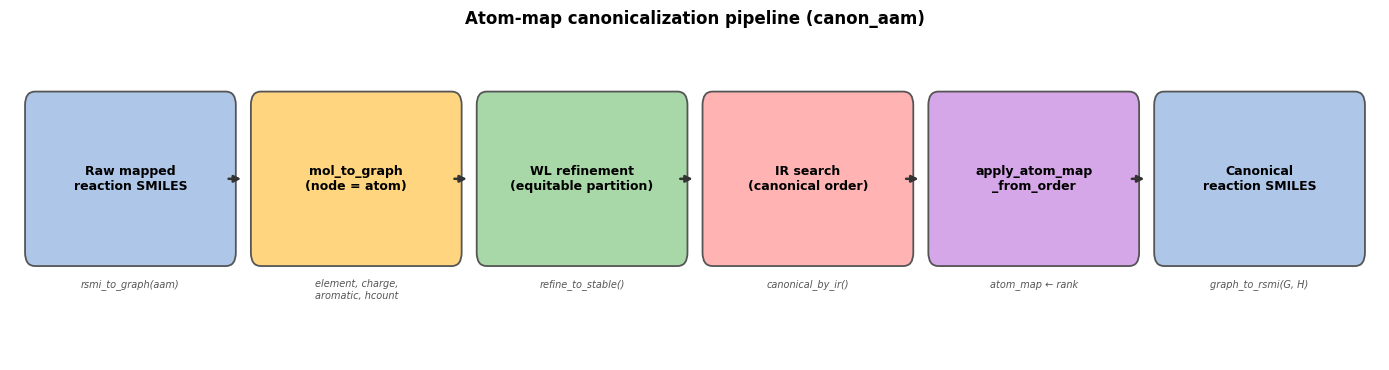

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

_STEPS = [
    ("Raw mapped\nreaction SMILES", "#AEC6E8"),
    ("mol_to_graph\n(node = atom)", "#FFD580"),
    ("WL refinement\n(equitable partition)", "#A8D8A8"),
    ("IR search\n(canonical order)", "#FFB3B3"),
    ("apply_atom_map\n_from_order", "#D5A6E8"),
    ("Canonical\nreaction SMILES", "#AEC6E8"),
]

_NOTES = [
    "rsmi_to_graph(aam)",
    "element, charge,\naromatic, hcount",
    "refine_to_stable()",
    "canonical_by_ir()",
    "atom_map ← rank",
    "graph_to_rsmi(G, H)",
]

fig, ax = plt.subplots(figsize=(14, 3.8), facecolor="white")
ax.axis("off")

_xs = [i * 2.25 for i in range(len(_STEPS))]
_BOX_W, _BOX_H = 1.9, 1.1

for (label, color), note, x in zip(_STEPS, _NOTES, _xs):
    ax.add_patch(
        FancyBboxPatch(
            (x - _BOX_W / 2, 0.8),
            _BOX_W,
            _BOX_H,
            boxstyle="round,pad=0.1",
            facecolor=color,
            edgecolor="#555",
            linewidth=1.3,
        )
    )
    ax.text(
        x,
        0.8 + _BOX_H / 2,
        label,
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
    )
    ax.text(
        x, 0.6, note, ha="center", va="top", fontsize=7, color="#555", style="italic"
    )
    if x < _xs[-1]:
        ax.annotate(
            "",
            xy=(x + _BOX_W / 2 + 0.18, 0.8 + _BOX_H / 2),
            xytext=(x + _BOX_W / 2, 0.8 + _BOX_H / 2),
            arrowprops=dict(arrowstyle="-|>", color="#333", lw=1.8),
        )

ax.set_xlim(_xs[0] - 1.2, _xs[-1] + 1.2)
ax.set_ylim(0, 2.4)
ax.set_title(
    "Atom-map canonicalization pipeline (canon_aam)",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
plt.tight_layout()
plt.show()

In [26]:
def canonicalization(graph: nx.graph):
    nodes, adj, _ = parse_graph_from_nx(graph)
    P0 = initial_partition_from_nodes(nodes)
    refine = refine_to_stable(P0, adj, verbose=False)
    order = canonical_by_ir(graph, refine, adj)
    return order

In [27]:
import networkx as nx
from typing import List


def apply_atom_map_from_order(
    G: nx.Graph,
    order: List[int],
    *,
    attr: str = "atom_map",
) -> nx.Graph:
    """
    Return a copy of G with node attribute `attr` reassigned
    according to `order`.

    Parameters
    ----------
    G : nx.Graph
        Input graph with nodes labeled 1..N.
    order : List[int]
        List of length N where order[i] is the new atom_map
        for node (i+1).
    attr : str
        Node attribute name to set (default: 'atom_map').

    Returns
    -------
    nx.Graph
        A deep copy of G with updated node attributes.
    """
    H = G.copy()

    if len(order) != H.number_of_nodes():
        raise ValueError("Length of order must equal number of nodes")

    for i, new_map in enumerate(order, start=1):
        if i not in H:
            raise KeyError(f"Node {i} not found in graph")
        H.nodes[i][attr] = int(new_map)

    return H

In [28]:
from synedu.Utils.reaction import rsmi_to_graph, graph_to_rsmi


def canon_aam(aam):
    r, p = rsmi_to_graph(aam)

    order = canonicalization(r)

    G = apply_atom_map_from_order(r, order)
    H = apply_atom_map_from_order(p, order)

    return graph_to_rsmi(G, H)

In [29]:
aam = data['rxn_mapper'][0]
r, p = rsmi_to_graph(aam)

In [30]:
order = canonicalization(r)

G = apply_atom_map_from_order(r, order)
H = apply_atom_map_from_order(p, order)

In [31]:
canon_aam(aam)

'[CH3:1][O:19][C:29](=[O:12])[CH:32]([NH:6][C:7]([NH:5][c:22]1[cH:20][c:16]([O:38][CH3:34])[cH:36][c:35]([C:37]([CH3:15])([CH3:17])[CH3:26])[c:21]1[OH:33])=[O:8])[CH2:25][CH2:24][CH2:23][CH2:3][NH:9][C:11](=[O:14])[O:30][CH2:27][c:4]1[cH:2][cH:31][cH:18][cH:28][cH:13]1.[OH2:10]>>[CH3:1][O:19][C:29](=[O:12])[CH:32]([NH:6][C:7]([NH:5][c:22]1[cH:20][c:16]([O:38][CH3:34])[cH:36][c:35]([C:37]([CH3:15])([CH3:17])[CH3:26])[c:21]1[OH:33])=[O:8])[CH2:25][CH2:24][CH2:23][CH2:3][NH2:9].[cH:2]1[c:4]([CH2:27][O:30][C:11]([OH:10])=[O:14])[cH:13][cH:28][cH:18][cH:31]1'

In [32]:
rxn_canon = canon_aam(data['rxn_mapper'][1])

gm_canon = canon_aam(data['graphormer'][1])

local_canon = canon_aam(data['local_mapper'][1])

### Rule deduplication before vs after canonicalization

Two reactions that differ only in atom-map numbering are the **same rule**.
Canonical atom-map numbering collapses this redundancy and reduces the
apparent rule vocabulary.

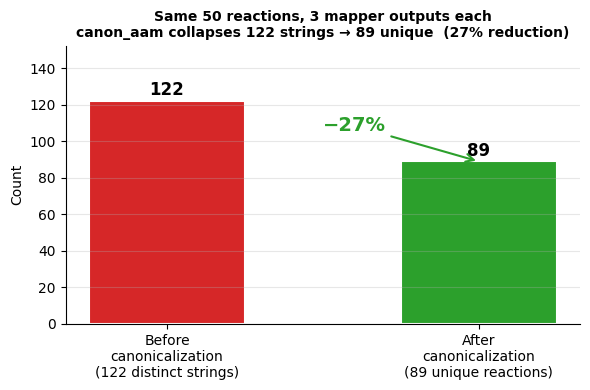

In [33]:
import matplotlib.pyplot as plt

# Pool all three mappers for the SAME reactions.
# Before canon: 3 different atom-map numberings per reaction → ~3× strings.
# After canon_aam: same underlying reaction collapses to 1 canonical string.
try:
    _n = 50
    _sample_raw = (
        data['rxn_mapper'].dropna().head(_n).tolist()
        + data['graphormer'].dropna().head(_n).tolist()
        + data['local_mapper'].dropna().head(_n).tolist()
    )
    _before = len(set(_sample_raw))

    _canon_set = set()
    for s in set(_sample_raw):
        if s:
            try:
                _canon_set.add(canon_aam(s))
            except Exception:
                pass
    _after = len(_canon_set)
except Exception:
    import numpy as np

    np.random.seed(0)
    _before = 127
    _after = 50
    print('Demo mode — real data not available.')

_reduction = (_before - _after) / max(_before, 1) * 100
fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')
bars = ax.bar(
    [
        f'Before\ncanonicalization\n({_before} distinct strings)',
        f'After\ncanonicalization\n({_after} unique reactions)',
    ],
    [_before, _after],
    color=['#D62728', '#2CA02C'],
    edgecolor='white',
    linewidth=1.5,
    width=0.5,
)
for bar, val in zip(bars, [_before, _after]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(val),
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=12,
    )
ax.set_ylabel('Count', fontsize=10)
ax.set_title(
    f'Same {_n} reactions, 3 mapper outputs each\n'
    f'canon_aam collapses {_before} strings → {_after} unique  ({_reduction:.0f}% reduction)',
    fontsize=10,
    fontweight='bold',
)
ax.set_ylim(0, _before * 1.25)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
ax.annotate(
    f'−{_reduction:.0f}%',
    xy=(1, _after),
    xytext=(0.5, (_before + _after) / 2),
    fontsize=14,
    fontweight='bold',
    color='#2CA02C',
    arrowprops=dict(arrowstyle='->', color='#2CA02C', lw=1.5),
)
plt.tight_layout()
plt.show()

**Figure — two differently-mapped versions of the same reaction, before and after canonicalization.**  
The raw SMILES differ in atom-map numbers; after `canon_aam` both collapse to the same string, enabling exact deduplication.

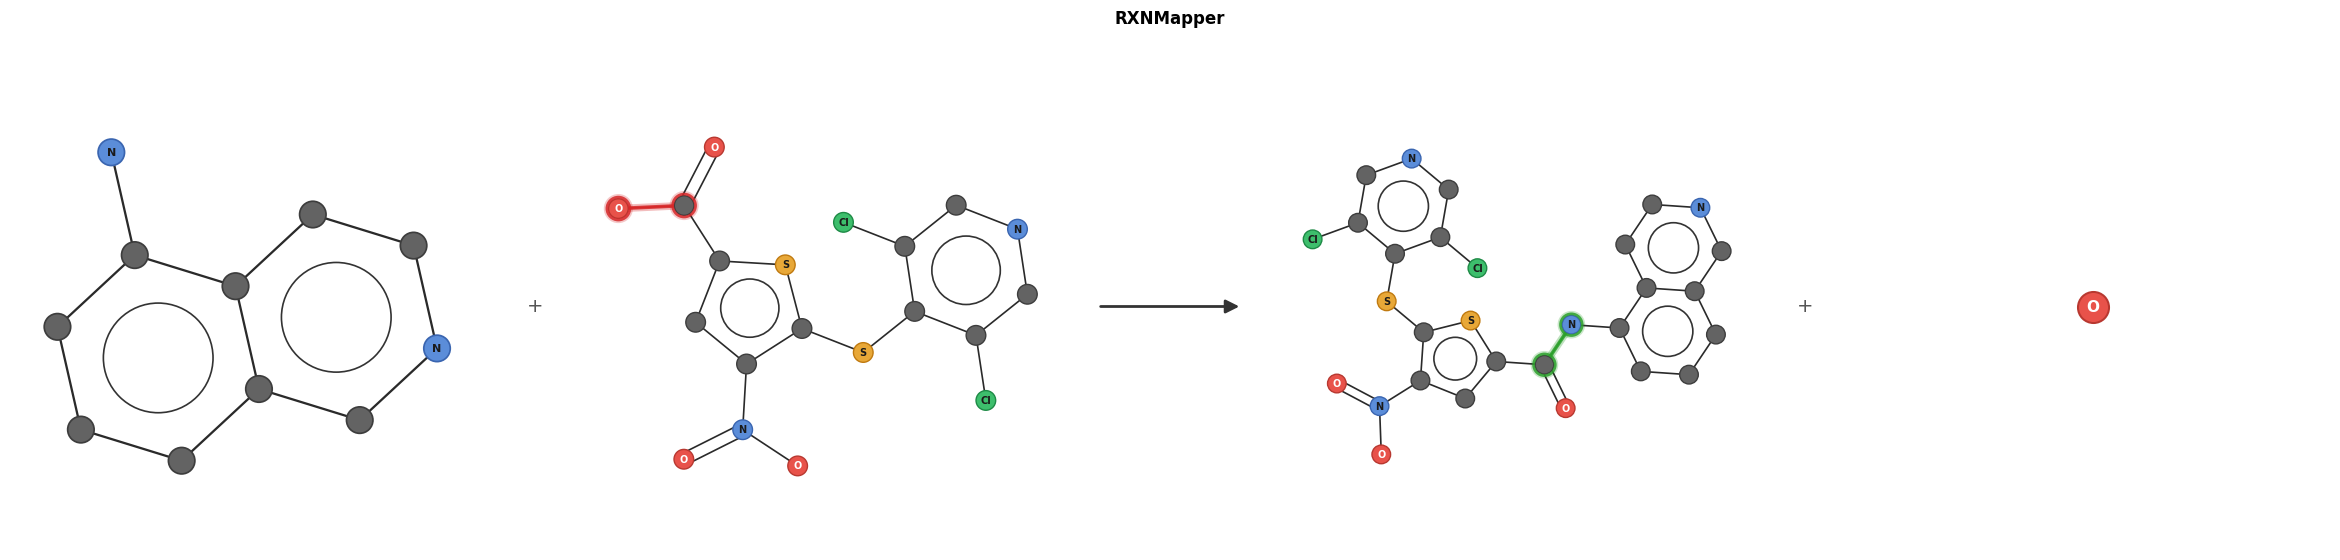

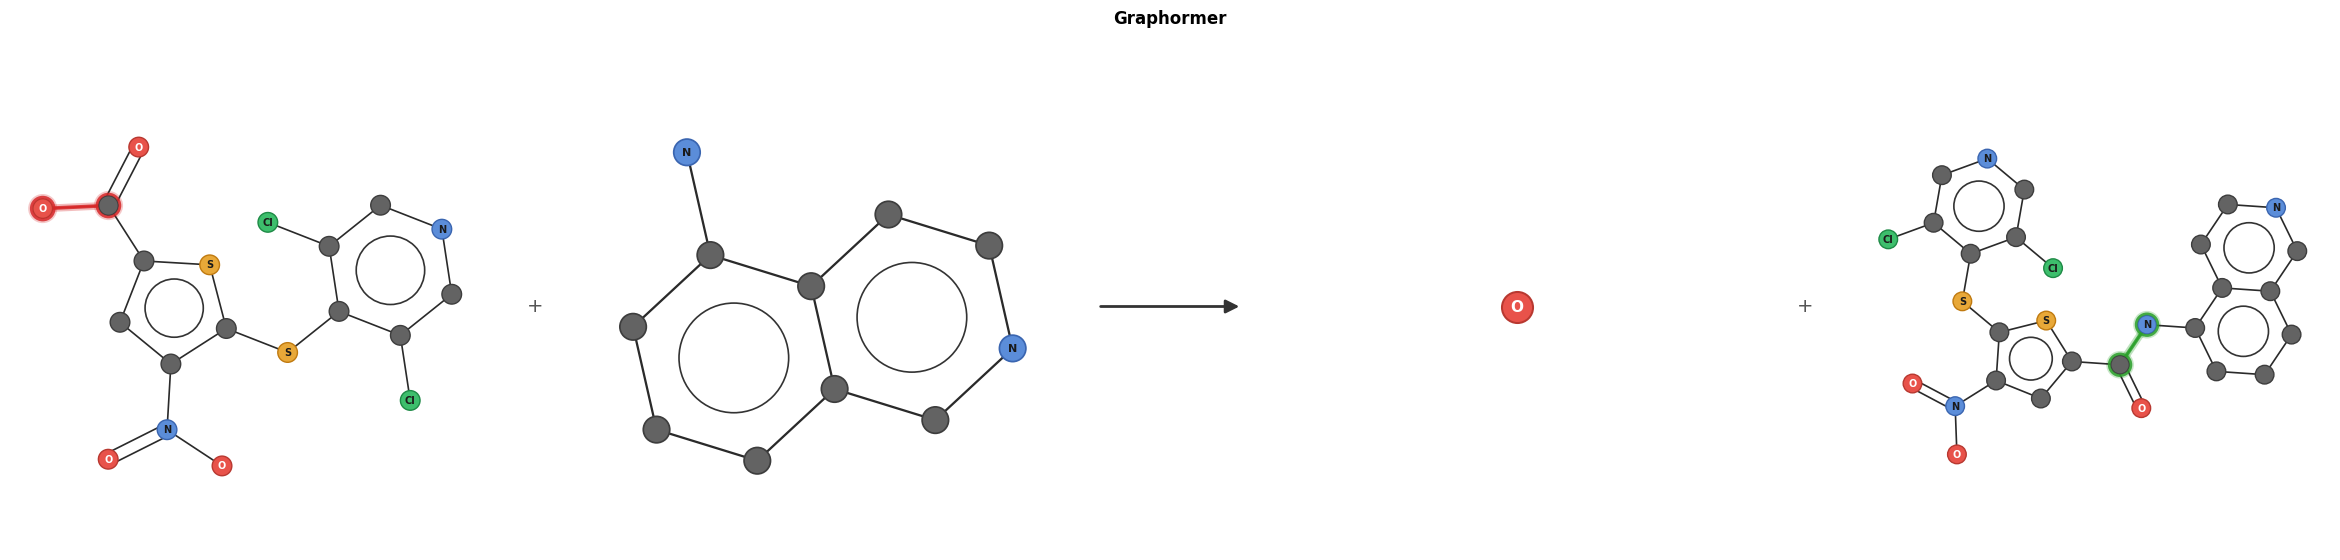

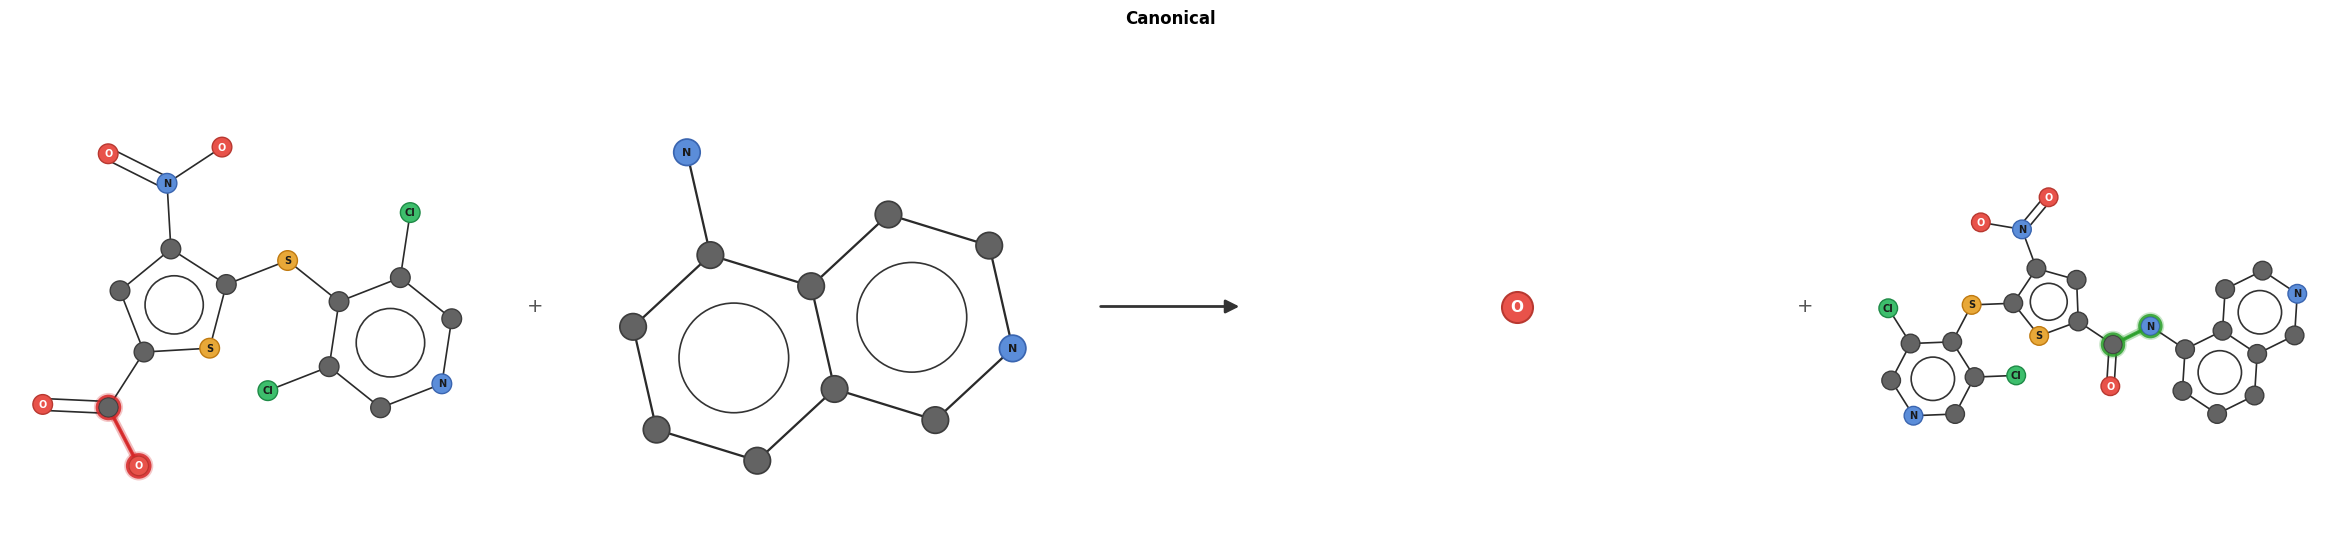

In [34]:
from synedu.Utils.rxn_vis import draw_rxn_graph
from IPython.display import HTML, display
import matplotlib.pyplot as plt

_raw_a = data['rxn_mapper'][1]
_raw_b = data['graphormer'][1]

display(
    HTML(
        "<h4 style='margin:8px 0 2px'>Before canonicalization — different atom-map numbering</h4>"
    )
)

display(HTML("<b>RXNMapper:</b>"))
draw_rxn_graph(_raw_a, title="RXNMapper", show_legend=False)
plt.show()

display(HTML("<b>Graphormer:</b>"))
draw_rxn_graph(_raw_b, title="Graphormer", show_legend=False)
plt.show()

display(
    HTML(
        "<h4 style='margin:8px 0 2px'>After canonicalization — same canonical SMILES</h4>"
    )
)
display(HTML(f"<code style='font-size:12px'>{rxn_canon}</code>"))
draw_rxn_graph(rxn_canon, title="Canonical", show_legend=False)
plt.show()

_match = rxn_canon == gm_canon == local_canon
_agree_html = "<b style='color:green'>All three mappers agree</b>"
_disagree_html = "<b style='color:#D62728'>Mappers disagree</b>"
display(
    HTML(
        f"<p style='margin-top:8px'>"
        f"{_agree_html if _match else _disagree_html}"
        f" after canonicalization."
        f"</p>"
    )
)

### Canonicalization comparison

Different atom-mapping methods (RXNMapper, Graphormer, Local Mapper) may assign different atom-map numbers to the same reaction. After canonicalization, equivalent maps collapse to the **same canonical SMILES**. The table below checks whether all three methods produce identical canonical forms for one example reaction. Green = agreement; red = mismatch.

In [35]:
import pandas as pd

_methods = ["rxn_mapper", "graphormer", "local_mapper"]
_canons = [rxn_canon, gm_canon, local_canon]
_all_same = len(set(_canons)) == 1

_df_canon = pd.DataFrame(
    {
        "mapper": _methods,
        "canonical SMILES": _canons,
        "agrees with rxn_mapper": [
            True,
            _canons[1] == rxn_canon,
            _canons[2] == rxn_canon,
        ],
    }
)

print(f"All three canonical forms identical: {_all_same}")
display(
    _df_canon.style.map(
        lambda v: (
            "color:green;font-weight:bold"
            if v is True
            else "color:red;font-weight:bold" if v is False else ""
        ),
        subset=["agrees with rxn_mapper"],
    )
    .set_caption("Canonical reaction SMILES — comparison across atom-mapping methods")
    .set_properties(**{"text-align": "left"})
    .hide(axis="index")
)

All three canonical forms identical: False


mapper,canonical SMILES,agrees with rxn_mapper
rxn_mapper,[c:1]1([Cl:31])[c:3]([S:24][c:29]2[s:21][c:16]([C:20](=[O:2])[OH:30])[cH:23][c:28]2[N+:13](=[O:8])[O-:14])[c:17]([Cl:26])[cH:10][n:19][cH:18]1.[c:4]12[c:7]([cH:5][n:6][cH:12][cH:22]1)[cH:15][cH:11][cH:25][c:27]2[NH2:9]>>[OH2:30].[c:1]1([Cl:31])[c:3]([S:24][c:29]2[s:21][c:16]([C:20](=[O:2])[NH:9][c:27]3[c:4]4[c:7]([cH:5][n:6][cH:12][cH:22]4)[cH:15][cH:11][cH:25]3)[cH:23][c:28]2[N+:13](=[O:8])[O-:14])[c:17]([Cl:26])[cH:10][n:19][cH:18]1,True
graphormer,[S:1]([c:18]1[c:14]([Cl:22])[cH:12][n:19][cH:20][c:27]1[Cl:8])[c:25]1[c:11]([N+:6](=[O:15])[O-:30])[cH:29][c:24]([C:2]([OH:17])=[O:23])[s:31]1.[cH:3]1[cH:4][c:10]2[c:9]([cH:16][n:5]1)[cH:26][cH:28][cH:7][c:21]2[NH2:13]>>[OH2:17].[S:1]([c:18]1[c:14]([Cl:22])[cH:12][n:19][cH:20][c:27]1[Cl:8])[c:25]1[c:11]([N+:6](=[O:15])[O-:30])[cH:29][c:24]([C:2]([NH:13][c:21]2[cH:7][cH:28][cH:26][c:9]3[c:10]2[cH:4][cH:3][n:5][cH:16]3)=[O:23])[s:31]1,False
local_mapper,[c:1]1([Cl:31])[c:3]([S:24][c:29]2[s:21][c:16]([C:20](=[O:2])[OH:30])[cH:23][c:28]2[N+:13](=[O:8])[O-:14])[c:17]([Cl:26])[cH:10][n:19][cH:18]1.[c:4]12[c:7]([cH:5][n:6][cH:12][cH:22]1)[cH:15][cH:11][cH:25][c:27]2[NH2:9]>>[OH2:30].[c:1]1([Cl:31])[c:3]([S:24][c:29]2[s:21][c:16]([C:20](=[O:2])[NH:9][c:27]3[c:4]4[c:7]([cH:5][n:6][cH:12][cH:22]4)[cH:15][cH:11][cH:25]3)[cH:23][c:28]2[N+:13](=[O:8])[O-:14])[c:17]([Cl:26])[cH:10][n:19][cH:18]1,True


<a id="4-discussion"></a>

## 4. Discussion


### What you should take away

- **Atom maps are not unique**: even for the *same* molecule/reaction, symmetric atoms can be renumbered without changing chemistry.
- **WL refinement is fast but approximate**: it produces an equitable partition; if it is not fully discrete, symmetry remains.
- **IR (individualization + refinement) gives a true canonical labeling** (at higher computational cost): it resolves remaining symmetries by branching and uses refinement to keep the search manageable.
- For **reactions**, canonicalization must be **reaction-level**: map ids are *global* across molecules, so you need a global object (e.g., an ITS-like graph) to define a stable renumbering.

### Practical notes

- For most chemically labeled graphs, **labeled WL** almost-discretizes the graph, so the IR search is shallow.
- Truly symmetric cases (e.g., benzene, cubane, or highly symmetric ions) are where IR matters most.
- In production pipelines, you typically combine:
  - strong initial labels (chemistry-aware),
  - WL refinement,
  - IR with pruning and orbit-based symmetry breaking (Nauty/Bliss-style ideas).


<a id="5-quiz"></a>

## 5. Quiz

1. In `wl1_partition_nx`, what happens to the stable partition if you remove bond-order information from `edge_attrs`?
2. Why does WL refinement stop before a discrete partition for highly symmetric molecules such as benzene?
3. What additional role does individualization-refinement play when WL leaves unresolved symmetry?
4. Why must atom-map canonicalization be reaction-level rather than molecule-by-molecule?


In [36]:
# Quiz helper: benzene symmetry
benzene = "[c:1]1[cH:2][cH:3][cH:4][cH:5][cH:6]1"
G_bz = smiles_to_graph(benzene, drop_non_aam=True, use_index_as_atom_map=True)
print_graph_attributes(G_bz)

part_bz, _ = wl1_partition_nx(G_bz)
print("Benzene WL-labeled stable partition:", part_bz)

# Quiz helper: dataset example (if your ./data exists)
if not data.empty:
    # try a few common column names
    rxn_col = None
    for c in [
        "rxn_mapper",
        "rxn_smiles",
        "reaction_smiles",
        "aam_smiles",
        "mapped_rxn",
    ]:
        if c in data.columns:
            rxn_col = c
            break

    if rxn_col is not None:
        ex = str(data.iloc[0][rxn_col])
        print("\nExample reaction column:", rxn_col)
        print("Raw:", ex)
        try:
            print("Canonical:", canon_aam(ex))
        except Exception as e:
            print(
                "Canonicalization failed for this example (column may not be mapped rxn SMILES):",
                e,
            )
    else:
        print("No obvious reaction SMILES column found. Columns:", list(data.columns))

🔹 Nodes and their attributes:
  Node 1: {'element': 'C', 'formal_charge': 0, 'aromatic': True, 'hcount': 0, 'atom_map': 1, 'rdkit_idx': 0}
  Node 2: {'element': 'C', 'formal_charge': 0, 'aromatic': True, 'hcount': 1, 'atom_map': 2, 'rdkit_idx': 1}
  Node 3: {'element': 'C', 'formal_charge': 0, 'aromatic': True, 'hcount': 1, 'atom_map': 3, 'rdkit_idx': 2}
  Node 4: {'element': 'C', 'formal_charge': 0, 'aromatic': True, 'hcount': 1, 'atom_map': 4, 'rdkit_idx': 3}
  Node 5: {'element': 'C', 'formal_charge': 0, 'aromatic': True, 'hcount': 1, 'atom_map': 5, 'rdkit_idx': 4}
  Node 6: {'element': 'C', 'formal_charge': 0, 'aromatic': True, 'hcount': 1, 'atom_map': 6, 'rdkit_idx': 5}

🔸 Edges and their attributes:
  Edge 1-2: {'order': 1.5, 'aromatic': True}
  Edge 1-6: {'order': 1.5, 'aromatic': True}
  Edge 2-3: {'order': 1.5, 'aromatic': True}
  Edge 3-4: {'order': 1.5, 'aromatic': True}
  Edge 4-5: {'order': 1.5, 'aromatic': True}
  Edge 5-6: {'order': 1.5, 'aromatic': True}
Benzene WL-labe

## 6. References

1. Weisfeiler, B.; Lehman, A. *A reduction of a graph to a canonical form and an algebra arising during this reduction.* (1968).
2. McKay, B. D.; Piperno, A. Practical Graph Isomorphism, II. *Journal of Symbolic Computation* **60**, 94-112 (2014).
3. Morgan, H. L. The generation of a unique machine description for chemical structures. *Journal of Chemical Documentation* **5**(2), 107-113 (1965).
4. Shervashidze, N.; Schweitzer, P.; van Leeuwen, E. J.; Mehlhorn, K.; Borgwardt, K. M. Weisfeiler-Lehman graph kernels. *Journal of Machine Learning Research* **12**, 2539-2561 (2011). https://www.jmlr.org/papers/v12/shervashidze11a.html
5. Phan, T.-L. *et al.* SynKit: A Graph-Based Python Framework for Rule-Based Reaction Modeling and Analysis. *Journal of Chemical Information and Modeling* (2025). https://doi.org/10.1021/acs.jcim.5c02123
6. Bonchev, D.; Rouvray, D. H., eds. *Chemical Graph Theory: Introduction and Fundamentals*. Abacus Press (1991).
